<div style="color: #0B39C9; font-size: 24px; font-weight: 700;">

DỰ ÁN: XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

</div>

# <span style="color: #E60000;">Notebook 06. Machine Learning</span>

*Huấn luyện, đánh giá và lựa chọn mô hình phân loại rủi ro tín dụng từ bộ đặc trưng `application_features` để bàn giao sang Notebook 06.1*

---

**Input:** Bảng `application_features` trong PostgreSQL (kết quả của Notebook 05), gồm dữ liệu đã làm sạch và các đặc trưng được lựa chọn cho mô hình.

**Output:** Kết quả so sánh các mô hình trên Validation, mô hình được lựa chọn cùng các artifact và metadata cần thiết để bàn giao sang Notebook 06.1 cho bước tối ưu ngưỡng dự đoán.

**Pipeline:** Business Understanding → Data Understanding → Database Organization → Data Cleaning → EDA & Visualization → Feature Engineering → **Machine Learning** → Prediction Demo


## I. Giới thiệu

### 1. Mục tiêu của Notebook 06

Huấn luyện và so sánh Logistic Regression, Random Forest và HistGradientBoosting để chọn mô hình dự đoán rủi ro tín dụng phù hợp nhất cho bài toán.

### 2. Vai trò của Machine Learning trong dự án


Mô hình biến các đặc trưng đã chuẩn bị thành xác suất rủi ro, từ đó hỗ trợ đánh giá hồ sơ vay một cách nhất quán thay vì phụ thuộc cảm tính của từng nhân viên tín dụng.

### 3. Mạch liên kết: Notebook 05 → Notebook 06 → Notebook 06_1

Notebook 05 bàn giao bảng `application_features`; Notebook 06 huấn luyện và so sánh các mô hình trên tập Validation để lựa chọn mô hình phù hợp nhất. Notebook 06.1 tiếp tục tối ưu ngưỡng dự đoán theo mục tiêu nghiệp vụ trước khi đánh giá cuối cùng trên tập Test và bàn giao sang Notebook 07.

## II. Đọc dữ liệu

Chuẩn bị thư viện

In [1]:
# Toan bo thu vien dung trong Notebook 06 duoc gom tai cell nay.
import json
import os
import time
from datetime import datetime
from pathlib import Path

import joblib
from sklearn.base import clone
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sqlalchemy import URL, create_engine

### 1. Đọc dữ liệu từ PostgreSQL (`application_features`)

In [2]:
# Xac dinh thu muc goc repo de moi artifact luon duoc luu vao <goc>/models,
# bat ke notebook duoc chay tu thu muc nao (VSCode, Jupyter hay nbconvert).
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "AGENTS.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "AGENTS.md").exists():
    raise FileNotFoundError("Khong xac dinh duoc thu muc goc repo (khong thay AGENTS.md).")

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
print(f"Thu muc goc du an: {PROJECT_ROOT}")
print(f"Thu muc luu mo hinh: {MODELS_DIR}")

Thu muc goc du an: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier
Thu muc luu mo hinh: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models


In [3]:
# Đọc dữ liệu bảng application_features từ database

env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
if not env_path.exists():
    raise FileNotFoundError("Không tìm thấy file .env chứa cấu hình PostgreSQL.")

load_dotenv(env_path)
db_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER", "postgres"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST", "localhost"),
    port=int(os.getenv("DB_PORT", "5432")),
    database=os.getenv("DB_NAME", "credit_risk_db"),
)
engine = create_engine(db_url)

df = pd.read_sql("SELECT * FROM public.application_features", engine)
assert {"sk_id_curr", "target"}.issubset(df.columns), (
    "Bảng application_features phải có sk_id_curr và target."
)
print(f"Đã đọc application_features: {df.shape[0]:,} dòng × {df.shape[1]:,} cột")
display(df.head())


Đã đọc application_features: 306,195 dòng × 234 cột


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,credit_card_balance_to_income,has_pos_cash_dpd,pos_cash_history_months,age_income_interaction,late_debt_interaction,ext_ltv_interaction,ext_credit_income_interaction,ext_dti_interaction,ext_min_ltv_interaction,ext_bureau_debt_interaction
0,112760,0,Cash loans,F,N,Y,0.0,135000.0,450000.0,24543.0,...,NaN,0,11.0,35-44 | Thấp,Không ghi nhận trễ | Thấp,0.705723,2.352409,0.128300,0.978805,0.175144
1,112761,0,Revolving loans,M,N,Y,0.0,193500.0,450000.0,22500.0,...,NaN,0,12.0,35-44 | Cao,Không ghi nhận trễ | Trung bình,0.450933,1.048681,0.052434,0.497122,0.119399
2,112762,0,Cash loans,F,N,Y,0.0,225000.0,781920.0,40486.5,...,NaN,0,NaN,25-34 | Cao,Không ghi nhận trễ | Cao,0.512698,1.538094,0.079640,0.677262,0.065402
3,112763,0,Cash loans,F,N,Y,0.0,72000.0,545040.0,20677.5,...,NaN,0,7.0,55+ | Rất thấp,Không ghi nhận trễ | Thấp,0.568609,3.553809,0.134823,0.671736,0.234200
4,112764,0,Cash loans,F,Y,Y,0.0,225000.0,742500.0,69421.5,...,NaN,0,5.0,55+ | Cao,NaN,0.374557,1.236037,0.115566,0.494002,NaN


### 2. Kiểm tra kích thước dữ liệu


In [4]:
# Tóm tắt kích thước và tỷ lệ thiếu của toàn bộ bảng.
tong_o = df.shape[0] * df.shape[1]
tong_thieu = int(df.isna().sum().sum())
ty_le_thieu = tong_thieu / tong_o * 100

input_summary = pd.DataFrame({
    "Chỉ tiêu": [
        "Số dòng",
        "Số cột",
        "Tổng giá trị thiếu",
        "Tỷ lệ giá trị thiếu",
    ],
    "Kết quả": [
        f"{df.shape[0]:,}",
        f"{df.shape[1]:,}",
        f"{tong_thieu:,}",
        f"{ty_le_thieu:.2f}%",
    ],
})

display(input_summary)

,Chỉ tiêu,Kết quả
0,Số dòng,"306,195"
1,Số cột,234
2,Tổng giá trị thiếu,"4,609,044"
3,Tỷ lệ giá trị thiếu,6.43%


### 3. Kiểm tra kiểu dữ liệu

In [5]:
# Đếm số cột theo từng kiểu dữ liệu.
dtype_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("Kiểu dữ liệu")
    .reset_index(name="Số cột")
)

so_cot_so = df.select_dtypes(include="number").shape[1]
so_cot_phan_loai = df.select_dtypes(exclude="number").shape[1]

assert so_cot_so + so_cot_phan_loai == df.shape[1]
display(dtype_summary)
print(f"Cột số: {so_cot_so:,} | Cột phân loại: {so_cot_phan_loai:,}")

,Kiểu dữ liệu,Số cột
0,float64,169
1,int64,46
2,str,19


Cột số: 215 | Cột phân loại: 19


### 4. Xác định Feature và Target

In [6]:
# Xác định vai trò của các cột; X và y được tạo ở Mục III.1.
ID_COLUMN = "sk_id_curr"
TARGET_COLUMN = "target"
so_feature = df.shape[1] - 2

assert {ID_COLUMN, TARGET_COLUMN}.issubset(df.columns)

role_summary = pd.DataFrame({
    "Vai trò": ["ID", "Target", "Feature ứng viên"],
    "Nội dung": [ID_COLUMN, TARGET_COLUMN, f"{so_feature:,} cột còn lại"],
})
display(role_summary)

,Vai trò,Nội dung
0,ID,sk_id_curr
1,Target,target
2,Feature ứng viên,232 cột còn lại


Đoạn code bên dưới kiểm tra phân bố của biến mục tiêu `target`.

In [7]:
# Đếm số hồ sơ và tỷ lệ của từng lớp target.
target_summary = (
    df["target"]
    .value_counts(dropna=False)
    .rename_axis("target")
    .reset_index(name="Số lượng")
)
target_summary["Tỷ lệ (%)"] = (
    target_summary["Số lượng"] / len(df) * 100
).round(2)

assert set(df["target"].dropna().unique()).issubset({0, 1}), (
    "target chỉ được chứa hai lớp 0 và 1."
)
display(target_summary)


,target,Số lượng,Tỷ lệ (%)
0,0,281427,91.91
1,1,24768,8.09


**Nhận xét:**

- Dữ liệu đầu vào có **306.195 dòng × 234 cột**, gồm 215 cột số và 19 cột phân loại.
- Target mất cân bằng rõ: nợ xấu chỉ chiếm **8,09%**. Vì vậy, Accuracy không đủ để lựa chọn mô hình; cần ưu tiên đọc PR-AUC, Precision, Recall và F1-score.
- Tỷ lệ thiếu 6,43% sẽ được xử lý sau khi chia dữ liệu; các tham số tiền xử lý được học từ Train rồi áp dụng cho Validation và Test để hạn chế Data Leakage.


## III. Chuẩn bị dữ liệu

### 1. Phát hiện các cột cần xử lý

#### a. Tạo Feature và Target

Đoạn code bên dưới tạo tập feature, target và loại hai interaction cần học lại từ tập Train.

In [8]:
# Tách feature và target.
X = df.drop(columns=[ID_COLUMN, TARGET_COLUMN]).copy()
y = df[TARGET_COLUMN].copy()

# Hai interaction này dùng ngưỡng dữ liệu nên phải tạo lại sau khi chia tập.
INTERACTION_HOC_LAI = ["age_income_interaction", "late_debt_interaction"]
interaction_co_san = [cot for cot in INTERACTION_HOC_LAI if cot in X.columns]
X = X.drop(columns=interaction_co_san)

assert ID_COLUMN not in X.columns
assert TARGET_COLUMN not in X.columns
assert len(X) == len(y)

print(f"Số feature trước khi xử lý: {X.shape[1]:,}")
print("Interaction sẽ tạo lại:", interaction_co_san)

Số feature trước khi xử lý: 230
Interaction sẽ tạo lại: ['age_income_interaction', 'late_debt_interaction']


#### b. Khảo sát các nhóm cột cần xử lý

Đoạn code bên dưới tìm cột phân loại, cột thiếu, cột vô hạn và cột chỉ có một giá trị.

In [9]:
# Phân loại cột theo vấn đề cần xử lý.
cot_so_khao_sat = X.select_dtypes(include="number").columns.tolist()
cot_phan_loai_khao_sat = X.select_dtypes(exclude="number").columns.tolist()
cot_co_missing = X.columns[X.isna().any()].tolist()
cot_hang_ung_vien = [cot for cot in X.columns if X[cot].nunique(dropna=False) <= 1]
cot_co_inf = [cot for cot in cot_so_khao_sat if np.isinf(X[cot].dropna()).any()]

problem_summary = pd.DataFrame({
    "Nhóm cần xử lý": [
        "Cột số", "Cột phân loại", "Cột có missing",
        "Cột có inf", "Cột hằng số ứng viên",
    ],
    "Số cột": [
        len(cot_so_khao_sat), len(cot_phan_loai_khao_sat),
        len(cot_co_missing), len(cot_co_inf), len(cot_hang_ung_vien),
    ],
})

display(problem_summary)
print("Cột có inf:", cot_co_inf)
print("Cột hằng số ứng viên:", cot_hang_ung_vien)

,Nhóm cần xử lý,Số cột
0,Cột số,213
1,Cột phân loại,17
2,Cột có missing,77
3,Cột có inf,0
4,Cột hằng số ứng viên,1


Cột có inf: []
Cột hằng số ứng viên: ['flag_mobil']


#### c. Xác định hướng xử lý

Đoạn code bên dưới lập bảng hướng xử lý cho từng nhóm cột.

In [10]:
# Kế hoạch xử lý trước khi huấn luyện.
processing_plan = pd.DataFrame({
    "Nhóm cột": [
        "ID và Target", "Interaction học từ dữ liệu", "Cột hằng số",
        "Cột số thiếu", "Cột phân loại thiếu", "Cột phân loại", "Cột số",
    ],
    "Hướng xử lý": [
        "Không đưa vào feature", "Tạo lại từ ngưỡng của Train",
        "Loại theo kết quả trên Train", "Điền 0 theo nghiệp vụ hoặc median từ Train",
        "Điền nhãn Unknown", "One-hot encoding", "Chuẩn hóa khi mô hình cần",
    ],
})

display(processing_plan)

,Nhóm cột,Hướng xử lý
0,ID và Target,Không đưa vào feature
1,Interaction học từ dữ liệu,Tạo lại từ ngưỡng của Train
2,Cột hằng số,Loại theo kết quả trên Train
3,Cột số thiếu,Điền 0 theo nghiệp vụ hoặc median từ Train
4,Cột phân loại thiếu,Điền nhãn Unknown
5,Cột phân loại,One-hot encoding
6,Cột số,Chuẩn hóa khi mô hình cần


### 2. Chia tập Train, Validation và Test

Đoạn code bên dưới tách riêng tập Test, sau đó chia phần dữ liệu còn lại thành Train và Validation. Tỷ lệ cuối cùng xấp xỉ 64% Train, 16% Validation và 20% Test, đồng thời sử dụng `stratify` để duy trì phân bố của biến mục tiêu.

In [11]:
# ============================================================
# Bước 1: Tách riêng 20% dữ liệu làm Test.
# Test không được sử dụng để lựa chọn mô hình.
# ============================================================

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# ============================================================
# Bước 2: Tách 20% phần Train + Validation làm Validation.
#
# Tỷ lệ trên toàn bộ dữ liệu:
# Train      ≈ 64%
# Validation ≈ 16%
# Test       = 20%
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val,
)

# Kiểm tra kích thước.
assert len(X_train) + len(X_val) + len(X_test) == len(X)

# Kiểm tra ba tập không trùng dòng.
assert X_train.index.intersection(X_val.index).empty
assert X_train.index.intersection(X_test.index).empty
assert X_val.index.intersection(X_test.index).empty

# Kiểm tra cùng cấu trúc feature.
assert list(X_train.columns) == list(X_val.columns)
assert list(X_train.columns) == list(X_test.columns)

split_summary = pd.DataFrame({
    "Tập dữ liệu": [
        "Train",
        "Validation",
        "Test",
    ],
    "Số dòng": [
        len(X_train),
        len(X_val),
        len(X_test),
    ],
    "Tỷ trọng (%)": [
        len(X_train) / len(X) * 100,
        len(X_val) / len(X) * 100,
        len(X_test) / len(X) * 100,
    ],
    "Tỷ lệ target=1 (%)": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100,
    ],
})

display(split_summary.round(2))

,Tập dữ liệu,Số dòng,Tỷ trọng (%),Tỷ lệ target=1 (%)
0,Train,195964,64.0,8.09
1,Validation,48992,16.0,8.09
2,Test,61239,20.0,8.09


**Nhận xét:**

- Dữ liệu được chia thành Train, Validation và Test theo tỷ lệ xấp xỉ **64% – 16% – 20%**.
- `stratify` giúp ba tập duy trì tỷ lệ khách hàng nợ xấu gần tương đương nhau.
- Tập Test được giữ riêng và chưa được sử dụng trong quá trình lựa chọn mô hình; việc so sánh Logistic Regression, Random Forest và HistGradientBoosting được thực hiện trên Validation.

### 3. Xử lý các cột có vấn đề

#### a. Loại cột không cung cấp thông tin

Đoạn code bên dưới học danh sách cột hằng số từ Train rồi loại cùng danh sách khỏi Validation và Test.

In [12]:
# Chỉ dùng Train để xác định các cột không có khả năng phân biệt.
constant_cols = [
    col
    for col in X_train.columns
    if X_train[col].nunique(dropna=False) <= 1
]

# Áp dụng cùng danh sách cột cho Validation và Test.
X_train = X_train.drop(columns=constant_cols)
X_val = X_val.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols)

assert list(X_train.columns) == list(X_val.columns)
assert list(X_train.columns) == list(X_test.columns)

print(f"Số cột hằng số đã loại: {len(constant_cols)}")
print("Danh sách:", constant_cols)

Số cột hằng số đã loại: 1
Danh sách: ['flag_mobil']


#### b. Tạo lại Interaction Features

Đoạn code bên dưới học các ngưỡng thu nhập và dư nợ từ tập Train để tạo lại hai interaction `age_income_interaction` và `late_debt_interaction`.

In [13]:
# Mốc tuổi cố định theo ý nghĩa nghiệp vụ.
TUOI_BINS = [0, 25, 35, 45, 55, np.inf]
TUOI_LABELS = ["<25", "25-34", "35-44", "45-54", "55+"]
NHAN_THU_NHAP = ["Rất thấp", "Thấp", "Trung bình", "Cao", "Rất cao"]
NHAN_DU_NO = ["Thấp", "Trung bình", "Cao", "Rất cao"]
TRE_HAN_COLS = ["bureau_max_overdue", "installments_max_late", "pos_cash_max_dpd"]
NHAN_THIEU = "Không rõ"


def hoc_nguong(cot, so_nhom):
    """Học các mốc phân vị từ một cột của tập Train."""
    _, moc = pd.qcut(cot.dropna(), q=so_nhom, retbins=True, duplicates="drop")
    moc[0], moc[-1] = -np.inf, np.inf
    return moc


nguong_thu_nhap = hoc_nguong(X_train["amt_income_total"], 5)
co_du_no = X_train["bureau_sum_debt"] > 0
nguong_du_no = hoc_nguong(X_train.loc[co_du_no, "bureau_sum_debt"], 4)

print("Ngưỡng thu nhập:", [f"{moc:,.0f}" for moc in nguong_thu_nhap[1:-1]])
print("Ngưỡng dư nợ:", [f"{moc:,.0f}" for moc in nguong_du_no[1:-1]])

Ngưỡng thu nhập: ['99,000', '135,000', '162,000', '225,000']
Ngưỡng dư nợ: ['139,916', '399,654', '992,387']


Đoạn code bên dưới dùng các ngưỡng đã học từ Train để tạo hai interaction cho Train, Validation và Test.

In [14]:
def tao_interaction(data):
    """Tạo interaction tuổi-thu nhập và trễ hạn-dư nợ."""
    data = data.copy()

    # Ghép nhóm tuổi với nhóm thu nhập.
    nhom_tuoi = pd.cut(data["age_years"], TUOI_BINS, labels=TUOI_LABELS)
    nhan_thu_nhap = NHAN_THU_NHAP[: len(nguong_thu_nhap) - 1]
    nhom_thu_nhap = pd.cut(data["amt_income_total"], nguong_thu_nhap, labels=nhan_thu_nhap)
    age_income = nhom_tuoi.astype("string") + " | " + nhom_thu_nhap.astype("string")
    data["age_income_interaction"] = age_income.fillna(NHAN_THIEU)

    # Ghép trạng thái trễ hạn với mức dư nợ.
    tung_tre = (data[TRE_HAN_COLS].fillna(0) > 0).any(axis=1)
    nhom_tre = pd.Series(
        np.where(tung_tre, "Từng trễ", "Không ghi nhận trễ"),
        index=data.index,
        dtype="string",
    )

    du_no = data["bureau_sum_debt"]
    nhom_du_no = pd.Series(NHAN_THIEU, index=data.index, dtype="string")
    nhom_du_no.loc[du_no == 0] = "Không còn dư nợ"
    co_du_no = du_no > 0
    nhan_du_no = NHAN_DU_NO[: len(nguong_du_no) - 1]
    nhom_du_no.loc[co_du_no] = pd.cut(
        du_no.loc[co_du_no], nguong_du_no, labels=nhan_du_no
    ).astype("string")

    data["late_debt_interaction"] = nhom_tre + " | " + nhom_du_no
    data.loc[data["has_bureau"].fillna(0) == 0, "late_debt_interaction"] = NHAN_THIEU
    return data


X_train = tao_interaction(X_train)
X_val = tao_interaction(X_val)
X_test = tao_interaction(X_test)

interaction_summary = pd.DataFrame({
    "Interaction": INTERACTION_HOC_LAI,
    "Số nhóm Train": [
        X_train[cot].nunique()
        for cot in INTERACTION_HOC_LAI
    ],
    "Số nhóm Validation": [
        X_val[cot].nunique()
        for cot in INTERACTION_HOC_LAI
    ],
    "Số nhóm Test": [
        X_test[cot].nunique()
        for cot in INTERACTION_HOC_LAI
    ],
})

display(interaction_summary)

,Interaction,Số nhóm Train,Số nhóm Validation,Số nhóm Test
0,age_income_interaction,25,25,25
1,late_debt_interaction,13,13,13


#### c. Xử lý giá trị thiếu

Đoạn code bên dưới định nghĩa các cột được điền 0 khi khách không có lịch sử tương ứng.

In [15]:
# Các cột khối lượng có thể điền 0 khi cờ lịch sử bằng 0.
COT_KHOI_LUONG = {
    "has_bureau": [
        "bureau_count", "bureau_sum_credit", "bureau_sum_debt", "bureau_max_overdue",
        "bureau_recent_loan_12m_count", "bureau_recent_12m_overdue_count",
        "bureau_balance_month_count",
        "bureau_balance_dpd_month_count", "bureau_balance_closed_month_count",
        "bureau_balance_unknown_month_count", "bureau_balance_delinquent_loan_count",
        "bureau_balance_max_dpd_status",
    ],
    "has_previous": [
        "previous_count", "previous_sum_credit", "previous_avg_credit",
        "previous_approved_count", "previous_refused_count",
        "previous_recent_12m_count", "previous_recent_12m_approved_count",
        "previous_recent_12m_refused_count", "previous_approved_sum_credit",
    ],
    "has_installments": [
        "installments_count", "installments_sum_due", "installments_sum_paid",
        "installments_avg_late", "installments_max_late",
        "installments_underpaid_count", "installments_underpaid_amount",
        "installments_recent_12m_late_count", "installments_recent_12m_count",
        "installments_recent_12m_underpaid_count",
        "installments_recent_12m_underpaid_amount",
    ],
    "has_pos_cash": [
        "pos_cash_count", "pos_cash_avg_dpd", "pos_cash_max_dpd",
        "pos_cash_contract_count", "pos_cash_recent_12m_dpd_count",
        "pos_cash_recent_12m_max_dpd",
    ],
    "has_credit_card": [
        "credit_card_count", "credit_card_avg_balance", "credit_card_max_balance",
        "credit_card_avg_limit", "credit_card_max_dpd",
        "credit_card_contract_count", "credit_card_avg_utilization",
        "credit_card_max_utilization",
        "credit_card_recent_12m_max_utilization",
    ],
}

# Chỉ giữ các cột thật sự có trong dữ liệu hiện tại.
COT_KHOI_LUONG = {
    co: [cot for cot in cac_cot if cot in X_train.columns]
    for co, cac_cot in COT_KHOI_LUONG.items()
    if co in X_train.columns
}

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
print(f"Cột số: {len(num_cols):,} | Cột phân loại: {len(cat_cols):,}")

Cột số: 212 | Cột phân loại: 19


Đoạn code bên dưới điền 0 theo cờ lịch sử, sau đó học median và nhãn thiếu từ Train.

In [16]:
def dien_0_lich_su(data):
    """Điền 0 cho khách không có lịch sử tương ứng."""
    data = data.copy()
    for co, cac_cot in COT_KHOI_LUONG.items():
        khong_co_lich_su = data[co] == 0
        data.loc[khong_co_lich_su, cac_cot] = (
            data.loc[khong_co_lich_su, cac_cot].fillna(0)
        )
    return data


thieu_truoc = [
    int(X_train.isna().sum().sum()),
    int(X_val.isna().sum().sum()),
    int(X_test.isna().sum().sum()),
]

X_train = dien_0_lich_su(X_train)
X_val = dien_0_lich_su(X_val)
X_test = dien_0_lich_su(X_test)

thieu_sau_0 = [
    int(X_train.isna().sum().sum()),
    int(X_val.isna().sum().sum()),
    int(X_test.isna().sum().sum()),
]

# Imputer chỉ học từ Train.
num_imputer = SimpleImputer(strategy="median", keep_empty_features=True)
cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index,
)

X_val_num = pd.DataFrame(
    num_imputer.transform(X_val[num_cols]),
    columns=num_cols,
    index=X_val.index,
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index,
)


def chuan_hoa_cot_chu(data):
    """Đổi ô thiếu ở cột chữ về dạng SimpleImputer hiểu được."""
    cot_chu = data[cat_cols].astype(object)
    return cot_chu.where(cot_chu.notna(), np.nan)


X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(
        chuan_hoa_cot_chu(X_train)
    ),
    columns=cat_cols,
    index=X_train.index,
)

X_val_cat = pd.DataFrame(
    cat_imputer.transform(
        chuan_hoa_cot_chu(X_val)
    ),
    columns=cat_cols,
    index=X_val.index,
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(
        chuan_hoa_cot_chu(X_test)
    ),
    columns=cat_cols,
    index=X_test.index,
)

assert not X_train_num.isna().any().any()
assert not X_val_num.isna().any().any()
assert not X_test_num.isna().any().any()

assert not X_train_cat.isna().any().any()
assert not X_val_cat.isna().any().any()
assert not X_test_cat.isna().any().any()

missing_summary = pd.DataFrame({
    "Tập dữ liệu": [
        "Train",
        "Validation",
        "Test",
    ],
    "Ô thiếu ban đầu": thieu_truoc,
    "Ô được điền 0": [
        truoc - sau
        for truoc, sau
        in zip(thieu_truoc, thieu_sau_0)
    ],
    "Ô còn lại dùng imputer": thieu_sau_0,
    "Ô thiếu sau xử lý": [0, 0, 0],
})

display(missing_summary)

,Tập dữ liệu,Ô thiếu ban đầu,Ô được điền 0,Ô còn lại dùng imputer,Ô thiếu sau xử lý
0,Train,2924115,1876431,1047684,0
1,Validation,725929,466133,259796,0
2,Test,907889,581240,326649,0


#### d. Mã hóa dữ liệu phân loại

Đoạn code bên dưới học các nhóm phân loại từ Train, sau đó one-hot encoding và áp dụng cùng cấu trúc feature cho Validation và Test.

In [17]:
# Encoder chỉ học các nhóm xuất hiện trong Train.
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train_cat)
encoded_cols = encoder.get_feature_names_out(cat_cols)


def build_matrix(data_num, data_cat, index):
    """Ghép cột số với cột phân loại đã mã hóa."""
    encoded = pd.DataFrame(
        encoder.transform(data_cat),
        columns=encoded_cols,
        index=index,
    )
    return pd.concat([data_num, encoded], axis=1)


X_train_prep = build_matrix(
    X_train_num,
    X_train_cat,
    X_train.index,
)

X_val_prep = build_matrix(
    X_val_num,
    X_val_cat,
    X_val.index,
)

X_test_prep = build_matrix(
    X_test_num,
    X_test_cat,
    X_test.index,
)

FEATURE_NAMES = X_train_prep.columns.tolist()

assert list(X_val_prep.columns) == FEATURE_NAMES
assert list(X_test_prep.columns) == FEATURE_NAMES
assert not X_train_prep.columns.duplicated().any()

display(pd.DataFrame({
    "Tập dữ liệu": [
        "Train",
        "Validation",
        "Test",
    ],
    "Số dòng": [
        len(X_train_prep),
        len(X_val_prep),
        len(X_test_prep),
    ],
    "Số cột trước mã hóa": [
        len(num_cols) + len(cat_cols)
    ] * 3,
    "Số cột sau mã hóa": [
        X_train_prep.shape[1],
        X_val_prep.shape[1],
        X_test_prep.shape[1],
    ],
}))

,Tập dữ liệu,Số dòng,Số cột trước mã hóa,Số cột sau mã hóa
0,Train,195964,231,397
1,Validation,48992,231,397
2,Test,61239,231,397


#### e. Chuẩn hóa dữ liệu khi cần

Đoạn code bên dưới chuẩn hóa các cột số có biến thiên; cột one-hot vẫn giữ nguyên 0/1.

In [18]:
# Chỉ chuẩn hóa cột số có nhiều hơn một giá trị.
cot_chuan_hoa = [
    cot for cot in num_cols
    if X_train_prep[cot].nunique(dropna=False) > 1
]

scaler = StandardScaler()
scaler.fit(X_train_prep[cot_chuan_hoa])


def chuan_hoa(data):
    """Chuẩn hóa cột số và giữ nguyên cột one-hot."""
    data = data.copy()
    data[cot_chuan_hoa] = scaler.transform(data[cot_chuan_hoa])
    return data

X_train_scaled = chuan_hoa(X_train_prep)
X_val_scaled = chuan_hoa(X_val_prep)
X_test_scaled = chuan_hoa(X_test_prep)

print(f"Số cột được chuẩn hóa: {len(cot_chuan_hoa):,}")
print(f"Số cột one-hot giữ nguyên: {len(encoded_cols):,}")

Số cột được chuẩn hóa: 212
Số cột one-hot giữ nguyên: 185


#### f. Kiểm tra dữ liệu cuối cùng

Đoạn code bên dưới kiểm tra ma trận đầu vào trước khi huấn luyện mô hình.

In [19]:
assert len(X_train_prep) == len(y_train)
assert len(X_val_prep) == len(y_val)
assert len(X_test_prep) == len(y_test)

assert list(X_train_prep.columns) == list(X_val_prep.columns)
assert list(X_train_prep.columns) == list(X_test_prep.columns)

for data in [
    X_train_prep,
    X_val_prep,
    X_test_prep,
]:
    assert data.select_dtypes(exclude="number").empty
    assert not data.isna().any().any()
    assert np.isfinite(data.to_numpy()).all()

final_summary = pd.DataFrame({
    "Tập dữ liệu": [
        "Train",
        "Validation",
        "Test",
    ],
    "Số dòng": [
        len(X_train_prep),
        len(X_val_prep),
        len(X_test_prep),
    ],
    "Số cột": [
        X_train_prep.shape[1],
        X_val_prep.shape[1],
        X_test_prep.shape[1],
    ],
    "Số ô thiếu": [
        int(X_train_prep.isna().sum().sum()),
        int(X_val_prep.isna().sum().sum()),
        int(X_test_prep.isna().sum().sum()),
    ],
})

display(final_summary)

,Tập dữ liệu,Số dòng,Số cột,Số ô thiếu
0,Train,195964,397,0
1,Validation,48992,397,0
2,Test,61239,397,0


**Nhận xét:**

- Sau xử lý missing và one-hot encoding, Train, Validation và Test có cùng cấu trúc feature và không còn giá trị thiếu.
- Các cột hằng số, ngưỡng interaction, median, nhóm phân loại, encoder và scaler đều được xác định hoặc fit từ tập Train.
- Validation được sử dụng để lựa chọn mô hình; Test được giữ riêng và chưa được sử dụng trong Notebook 06, giúp hạn chế Data Leakage và tránh lựa chọn mô hình dựa trên kết quả Test.

## IV. Mô hình Logistic Regression

### 1. Giới thiệu Logistic Regression

Logistic Regression là mô hình phân loại tuyến tính, dùng các feature đầu vào để ước tính xác suất khách hàng thuộc nhóm nợ xấu (`target=1`).

Mỗi feature có thể làm mức rủi ro tăng hoặc giảm. Ví dụ, lịch sử quá hạn có thể làm rủi ro tăng, còn điểm đánh giá ngoài cao có thể làm rủi ro giảm. Sau khi tổng hợp các yếu tố, mô hình trả về một xác suất từ 0 đến 1.

Ví dụ, xác suất `0,12` có nghĩa mô hình đánh giá hồ sơ có mức rủi ro nợ xấu 12%; xác suất `0,68` tương ứng mức rủi ro 68%. Nếu tạm dùng ngưỡng `0,5`, hồ sơ `0,68` được xếp vào nhóm nợ xấu, còn hồ sơ `0,12` được xếp vào nhóm trả được nợ.

Trong NB06, Logistic Regression được dùng làm mô hình nền vì huấn luyện nhanh và có thể giải thích thông qua hệ số của từng feature.

### 2. Lựa chọn feature đầu vào

Đoạn code bên dưới sử dụng toàn bộ feature đã xử lý và chuẩn hóa ở Mục III. Tập Train được dùng để huấn luyện Logistic Regression, còn tập Validation được dùng để đánh giá và so sánh với các mô hình khác.

In [31]:
# Logistic Regression sử dụng dữ liệu đã chuẩn hóa.
X_train_lr = X_train_scaled
X_val_lr = X_val_scaled

# Kiểm tra Train và Validation có cùng cấu trúc feature.
assert list(X_train_lr.columns) == FEATURE_NAMES
assert list(X_val_lr.columns) == FEATURE_NAMES

# Kiểm tra không còn giá trị thiếu.
assert not X_train_lr.isna().any().any()
assert not X_val_lr.isna().any().any()

Đoạn code bên dưới tóm tắt kích thước dữ liệu đầu vào của Logistic Regression.

In [32]:
feature_summary_lr = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation"],
    "Số dòng": [
        len(X_train_lr),
        len(X_val_lr),
    ],
    "Số feature": [
        X_train_lr.shape[1],
        X_val_lr.shape[1],
    ],
    "Số ô thiếu": [
        int(X_train_lr.isna().sum().sum()),
        int(X_val_lr.isna().sum().sum()),
    ],
})

display(feature_summary_lr)

,Tập dữ liệu,Số dòng,Số feature,Số ô thiếu
0,Train,195964,397,0
1,Validation,48992,397,0


### 3. Huấn luyện mô hình

Do nhóm nợ xấu chỉ chiếm khoảng 8% dữ liệu, Logistic Regression sử dụng `class_weight="balanced"` để tăng trọng số tương đối cho lớp thiểu số. Mô hình được huấn luyện hoàn toàn trên tập Train.

In [33]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
)

bat_dau = time.time()

lr_model.fit(
    X_train_lr,
    y_train,
)

thoi_gian_lr = time.time() - bat_dau

Đoạn code bên dưới kiểm tra số vòng lặp và xác nhận Logistic Regression đã hội tụ trước giới hạn tối đa.

In [34]:
so_vong_lap = int(lr_model.n_iter_[0])

assert so_vong_lap < lr_model.max_iter, (
    "Logistic Regression chưa hội tụ."
)

print(f"Thời gian huấn luyện: {thoi_gian_lr:.1f} giây")
print(f"Số vòng lặp: {so_vong_lap} / {lr_model.max_iter}")

Thời gian huấn luyện: 24.3 giây
Số vòng lặp: 190 / 1000


### 4. Dự đoán trên tập Validation

Đoạn code bên dưới lấy xác suất khách hàng thuộc nhóm nợ xấu (`target=1`) trên tập Validation.

In [35]:
y_val_proba_lr = lr_model.predict_proba(
    X_val_lr
)[:, 1]

assert len(y_val_proba_lr) == len(y_val)

assert np.all(
    (y_val_proba_lr >= 0)
    & (y_val_proba_lr <= 1)
)

Ngưỡng `0,5` được sử dụng tạm thời trong Notebook 06 để chuyển xác suất thành nhãn dự đoán và giúp ba mô hình được so sánh trong cùng điều kiện. Ngưỡng dự đoán cuối cùng sẽ được lựa chọn riêng tại Notebook 06.1.

In [36]:
NGUONG_TAM_THOI_LR = 0.5

y_val_pred_lr = (
    y_val_proba_lr >= NGUONG_TAM_THOI_LR
).astype(int)

Đoạn code bên dưới hiển thị 10 dự đoán đầu tiên trên tập Validation để minh họa kết quả của mô hình.

In [37]:
prediction_sample_lr = pd.DataFrame({
    "Nhãn thực tế": y_val.iloc[:10].to_numpy(),
    "Xác suất nợ xấu": y_val_proba_lr[:10],
    "Nhãn dự đoán": y_val_pred_lr[:10],
}, index=y_val.index[:10])

display(
    prediction_sample_lr.round(4)
)

,Nhãn thực tế,Xác suất nợ xấu,Nhãn dự đoán
174344,0,0.7561,1
194595,0,0.2480,0
248713,1,0.9136,1
34504,0,0.4222,0
253056,0,0.6346,1
32721,0,0.6598,1
284781,0,0.3790,0
95590,1,0.9068,1
78746,0,0.4421,0
284304,0,0.6153,1


### 5. Đánh giá mô hình

Logistic Regression được đánh giá trên tập Validation để phục vụ việc lựa chọn mô hình trong Notebook 06.

Vì nhóm nợ xấu chỉ chiếm khoảng 8%, Accuracy không đủ để phản ánh đầy đủ hiệu quả mô hình. Do đó, phần đánh giá tập trung vào ma trận nhầm lẫn, Precision, Recall, F1-score, ROC-AUC và PR-AUC.

#### a. Ma trận nhầm lẫn

Ma trận nhầm lẫn chia kết quả dự đoán thành bốn trường hợp:

| Thực tế | Dự đoán | Ý nghĩa |
|---|---|---|
| Trả được nợ | Trả được nợ | Dự đoán đúng khách trả được nợ |
| Trả được nợ | Nợ xấu | Cảnh báo nhầm |
| Nợ xấu | Trả được nợ | Bỏ sót khách nợ xấu |
| Nợ xấu | Nợ xấu | Phát hiện đúng khách nợ xấu |

Đoạn code bên dưới tính ma trận nhầm lẫn của Logistic Regression trên tập Validation tại ngưỡng `0,5`.

In [39]:
CLASS_LABELS = [
    "Trả được nợ (0)",
    "Nợ xấu (1)",
]

ma_tran_lr = confusion_matrix(
    y_val,
    y_val_pred_lr,
)

tn_lr, fp_lr, fn_lr, tp_lr = ma_tran_lr.ravel()

bang_ma_tran_lr = pd.DataFrame(
    ma_tran_lr,
    index=[
        "Thực tế: Trả được nợ",
        "Thực tế: Nợ xấu",
    ],
    columns=[
        "Dự đoán: Trả được nợ",
        "Dự đoán: Nợ xấu",
    ],
)

display(bang_ma_tran_lr)

print(f"Phát hiện đúng nợ xấu: {tp_lr:,}")
print(f"Bỏ sót nợ xấu: {fn_lr:,}")
print(f"Cảnh báo nhầm: {fp_lr:,}")

,Dự đoán: Trả được nợ,Dự đoán: Nợ xấu
Thực tế: Trả được nợ,31983,13046
Thực tế: Nợ xấu,1236,2727


Phát hiện đúng nợ xấu: 2,727
Bỏ sót nợ xấu: 1,236
Cảnh báo nhầm: 13,046


Đoạn code bên dưới trực quan hóa ma trận nhầm lẫn để dễ quan sát các trường hợp dự đoán đúng và dự đoán sai.

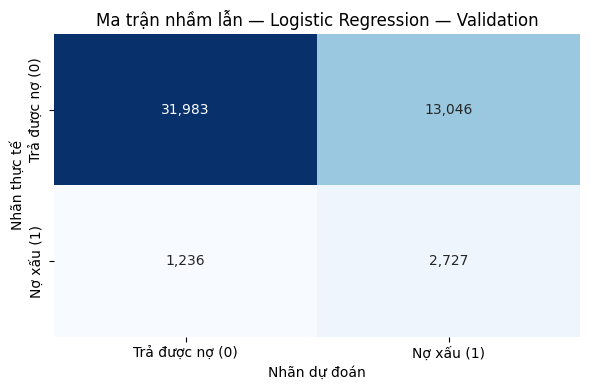

In [40]:
get_ipython().run_line_magic(
    "matplotlib",
    "inline",
)

fig, ax = plt.subplots(
    figsize=(6, 4)
)

sns.heatmap(
    ma_tran_lr,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=ax,
)

ax.set_xlabel("Nhãn dự đoán")
ax.set_ylabel("Nhãn thực tế")
ax.set_title(
    "Ma trận nhầm lẫn — Logistic Regression — Validation"
)

fig.tight_layout()
plt.show()

#### b. Các chỉ số đánh giá

- **Precision:** trong số khách bị dự đoán là nợ xấu, có bao nhiêu người thực sự nợ xấu.
- **Recall:** trong số khách thực sự nợ xấu, mô hình phát hiện được bao nhiêu người.
- **F1-score:** điểm cân bằng giữa Precision và Recall.
- **ROC-AUC:** khả năng xếp khách nợ xấu có mức rủi ro cao hơn khách trả được nợ.
- **PR-AUC:** phản ánh khả năng phát hiện lớp nợ xấu trong bối cảnh dữ liệu mất cân bằng.

Đoạn code bên dưới tính các metric của Logistic Regression trên tập Validation để phục vụ bước so sánh với Random Forest và HistGradientBoosting.

In [41]:
chi_so_lr_val = {
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_proba_lr,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_proba_lr,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_lr,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_lr,
        zero_division=0,
    ),
    "F1-Score": f1_score(
        y_val,
        y_val_pred_lr,
        zero_division=0,
    ),
}

Đoạn code bên dưới hiển thị các metric và tỷ lệ nợ xấu thực tế của tập Validation.

In [42]:
bang_chi_so_lr = pd.DataFrame(
    [chi_so_lr_val],
    index=["Logistic Regression"],
)

display(
    bang_chi_so_lr.round(4)
)

print(
    f"Tỷ lệ nợ xấu thực tế ở Validation: "
    f"{y_val.mean():.4f}"
)

,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
Logistic Regression,0.7667,0.2463,0.1729,0.6881,0.2763


Tỷ lệ nợ xấu thực tế ở Validation: 0.0809


**Nhận xét:**

- Logistic Regression được sử dụng làm mô hình baseline và được đánh giá trên tập Validation tại ngưỡng tạm thời `0,5`.
- Recall phản ánh khả năng phát hiện khách hàng nợ xấu, trong khi Precision phản ánh mức chính xác của các cảnh báo rủi ro.
- ROC-AUC, PR-AUC, Precision, Recall và F1-score sẽ được sử dụng để so sánh Logistic Regression với hai mô hình còn lại.
- Các giá trị cụ thể sẽ được diễn giải sau khi Notebook 06 được chạy lại hoàn chỉnh với cấu trúc Train–Validation–Test mới.

### 6. Giải thích mô hình bằng hệ số

Đoạn code bên dưới ghép hệ số của mô hình với đúng tên feature.

In [43]:
he_so = pd.Series(
    lr_model.coef_[0],
    index=FEATURE_NAMES,
).sort_values()

Đoạn code bên dưới định nghĩa hàm dùng để đếm số khách hàng thuộc từng nhóm one-hot trong tập Train.

In [44]:
def dem_khach_trong_nhom(ten_cot):
    """Đếm số khách Train thuộc một nhóm one-hot."""
    if ten_cot in encoded_cols:
        return f"{int((X_train_prep[ten_cot] == 1).sum()):,}"

    return "(cột số)"

Đoạn code bên dưới lấy 10 hệ số âm nhất và 10 hệ số dương nhất để xác định các feature có hệ số nổi bật.

In [45]:
cac_cot_noi_bat = (
    list(he_so.head(10).index)
    + list(he_so.tail(10).index)
)

bang_he_so = pd.DataFrame({
    "Feature": cac_cot_noi_bat,
    "Hệ số": [
        round(float(he_so[cot]), 4)
        for cot in cac_cot_noi_bat
    ],
    "Chiều tác động": [
        "Giảm rủi ro"
        if he_so[cot] < 0
        else "Tăng rủi ro"
        for cot in cac_cot_noi_bat
    ],
    "Số khách thuộc nhóm (Train)": [
        dem_khach_trong_nhom(cot)
        for cot in cac_cot_noi_bat
    ],
})

display(bang_he_so)

,Feature,Hệ số,Chiều tác động,Số khách thuộc nhóm (Train)
0,name_education_type_Academic degree,-0.6943,Giảm rủi ro,113
1,name_type_suite_Missing,-0.4258,Giảm rủi ro,664
2,organization_type_Military,-0.3911,Giảm rủi ro,"1,721"
3,organization_type_Trade: type 4,-0.3769,Giảm rủi ro,42
4,age_income_interaction_55+ | Rất cao,-0.3753,Giảm rủi ro,"4,776"
5,organization_type_Industry: type 2,-0.3732,Giảm rủi ro,292
6,organization_type_Industry: type 12,-0.3711,Giảm rủi ro,228
7,years_build_medi,-0.3555,Giảm rủi ro,(cột số)
8,age_income_interaction_55+ | Rất thấp,-0.3528,Giảm rủi ro,"13,209"
9,organization_type_Transport: type 1,-0.3308,Giảm rủi ro,129


Đoạn code bên dưới kiểm tra số lượng feature có hệ số gần 0 trong Logistic Regression.

In [46]:
so_cot_gan_0 = int(
    (he_so.abs() < 0.01).sum()
)

print(
    f"Số feature có hệ số gần 0: "
    f"{so_cot_gan_0:,} / {len(he_so):,}"
)

Số feature có hệ số gần 0: 37 / 397


Đoạn code bên dưới trực quan hóa 20 feature có hệ số nổi bật. Màu xanh biểu diễn hệ số âm và màu đỏ biểu diễn hệ số dương.

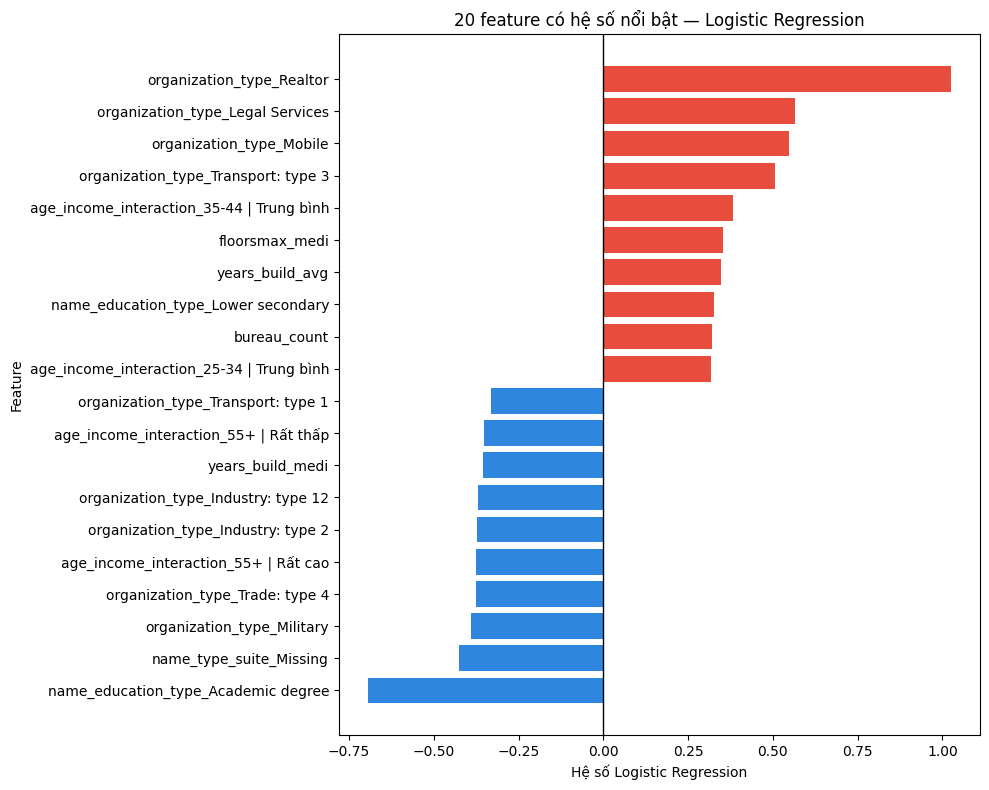

In [47]:
get_ipython().run_line_magic(
    "matplotlib",
    "inline",
)

he_so_noi_bat = he_so.loc[
    cac_cot_noi_bat
]

mau_he_so = [
    "#2E86DE"
    if gia_tri < 0
    else "#E74C3C"
    for gia_tri in he_so_noi_bat
]

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    he_so_noi_bat.index,
    he_so_noi_bat.values,
    color=mau_he_so,
)

ax.axvline(
    0,
    color="black",
    linewidth=1,
)

ax.set_xlabel(
    "Hệ số Logistic Regression"
)

ax.set_ylabel("Feature")

ax.set_title(
    "20 feature có hệ số nổi bật — Logistic Regression"
)

fig.tight_layout()
plt.show()

**Nhận xét:**

- Các hệ số cho thấy Logistic Regression sử dụng đồng thời nhiều nhóm feature để phân biệt mức rủi ro tín dụng.
- Hệ số dương và âm thể hiện chiều tác động của feature lên dự đoán trong mô hình tuyến tính.
- Một số nhóm one-hot có thể có ít quan sát trong Train, vì vậy các hệ số có giá trị tuyệt đối lớn cần được diễn giải thận trọng.
- Hệ số của mô hình không chứng minh feature là nguyên nhân trực tiếp làm phát sinh nợ xấu.

### 7. Lưu mô hình Logistic Regression

Đoạn code bên dưới tạo metadata của Logistic Regression từ kết quả đánh giá trên tập Validation. Ngưỡng `0,5` chỉ là ngưỡng tạm thời dùng để so sánh mô hình trong Notebook 06.

In [48]:
metrics_lr = {
    "model_name":
        "Credit Risk Classification - Logistic Regression",

    "model_type":
        type(lr_model).__name__,

    "model_version":
        "1.0.0",

    "status":
        "Candidate",

    "dataset":
        "application_features",

    "target":
        TARGET_COLUMN,

    "trained_date":
        datetime.now().strftime("%Y-%m-%d %H:%M"),

    "trained_from":
        "06_modeling_evaluation.ipynb",

    "train_rows":
        len(X_train_lr),

    "validation_rows":
        len(X_val_lr),

    "data_split":
        "64/16/20 Stratified",

    "features_count":
        len(FEATURE_NAMES),

    "decision_threshold":
        NGUONG_TAM_THOI_LR,

    "roc_auc_validation":
        round(float(chi_so_lr_val["ROC-AUC"]), 4),

    "pr_auc_validation":
        round(float(chi_so_lr_val["PR-AUC"]), 4),

    "precision_validation":
        round(float(chi_so_lr_val["Precision"]), 4),

    "recall_validation":
        round(float(chi_so_lr_val["Recall"]), 4),

    "f1_validation":
        round(float(chi_so_lr_val["F1-Score"]), 4),

    "confusion_matrix_validation":
        ma_tran_lr.tolist(),

    "author":
        "Nhóm 01",
}

Đoạn code bên dưới đóng gói Logistic Regression cùng danh sách feature, ngưỡng tạm thời và metric Validation.

In [49]:
goi_logistic = {
    "model": lr_model,
    "feature_names": FEATURE_NAMES,
    "can_chuan_hoa": True,
    "nguong_tam_thoi": NGUONG_TAM_THOI_LR,
    "metrics_validation": metrics_lr,
}

Đoạn code bên dưới xác định đường dẫn lưu mô hình và file metric của Logistic Regression.

In [50]:
duong_dan_lr = (
    MODELS_DIR
    / "logistic_regression.pkl"
)

duong_dan_metrics_lr = (
    MODELS_DIR
    / "logistic_regression_metrics.json"
)

Đoạn code bên dưới lưu mô hình Logistic Regression vào thư mục `models`.

In [51]:
joblib.dump(
    goi_logistic,
    duong_dan_lr,
)

print(
    f"Đã lưu mô hình: "
    f"{duong_dan_lr}"
)

Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\logistic_regression.pkl


Đoạn code bên dưới lưu metadata và metric Validation của Logistic Regression dưới dạng JSON.

In [52]:
duong_dan_metrics_lr.write_text(
    json.dumps(
        metrics_lr,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    f"Đã lưu metric: "
    f"{duong_dan_metrics_lr}"
)

Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\logistic_regression_metrics.json


Đoạn code bên dưới hiển thị lại các metric chính đã lưu để kiểm tra kết quả.

In [53]:
display(
    pd.DataFrame(
        [{
            "ROC-AUC":
                metrics_lr["roc_auc_validation"],

            "PR-AUC":
                metrics_lr["pr_auc_validation"],

            "Precision":
                metrics_lr["precision_validation"],

            "Recall":
                metrics_lr["recall_validation"],

            "F1-Score":
                metrics_lr["f1_validation"],
        }],
        index=[
            "Logistic Regression"
        ],
    )
)

,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
Logistic Regression,0.7667,0.2463,0.1729,0.6881,0.2763


## V. Mô hình Random Forest

### 1. Giới thiệu Random Forest

Random Forest là mô hình kết hợp nhiều cây quyết định. Mỗi cây học từ một phần dữ liệu và đưa ra dự đoán riêng; kết quả cuối cùng được tổng hợp từ tất cả các cây.

Có thể hình dung 300 nhân viên tín dụng cùng đánh giá một hồ sơ. Mỗi người xem một số thông tin khác nhau, sau đó tổng hợp ý kiến để xác định rủi ro.

Khác với Logistic Regression, Random Forest có thể học các quan hệ phi tuyến và tương tác phức tạp giữa các feature. Mô hình cũng cung cấp Feature Importance để xem những feature được sử dụng nhiều trong quá trình dự đoán.

### 2. Lựa chọn feature đầu vào

Đoạn code bên dưới sử dụng toàn bộ feature đã xử lý ở Mục III. Random Forest không bắt buộc chuẩn hóa dữ liệu.

In [54]:
# Random Forest sử dụng dữ liệu đã xử lý nhưng chưa chuẩn hóa.
X_train_rf = X_train_prep
X_val_rf = X_val_prep

# Kiểm tra Train và Validation có cùng cấu trúc feature.
assert list(X_train_rf.columns) == FEATURE_NAMES
assert list(X_val_rf.columns) == FEATURE_NAMES

# Kiểm tra không còn giá trị thiếu.
assert not X_train_rf.isna().any().any()
assert not X_val_rf.isna().any().any()

Đoạn code bên dưới tóm tắt kích thước dữ liệu đầu vào của Random Forest.

In [55]:
bang_du_lieu_rf = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation"],
    "Số dòng": [
        len(X_train_rf),
        len(X_val_rf),
    ],
    "Số feature": [
        X_train_rf.shape[1],
        X_val_rf.shape[1],
    ],
    "Số ô thiếu": [
        int(X_train_rf.isna().sum().sum()),
        int(X_val_rf.isna().sum().sum()),
    ],
})

display(bang_du_lieu_rf)

,Tập dữ liệu,Số dòng,Số feature,Số ô thiếu
0,Train,195964,397,0
1,Validation,48992,397,0


### 3. Huấn luyện mô hình

Các tham số chính của Random Forest:

- `n_estimators=300`: xây dựng 300 cây quyết định.
- `max_depth=12`: giới hạn độ sâu tối đa của mỗi cây.
- `min_samples_leaf=50`: mỗi nút lá phải có ít nhất 50 khách hàng.
- `class_weight="balanced"`: điều chỉnh trọng số để tăng mức quan tâm tới lớp nợ xấu đang chiếm tỷ lệ thấp.
- `random_state=42`: giúp kết quả có thể lặp lại.

Đoạn code bên dưới khởi tạo và huấn luyện Random Forest trên tập Train.

In [56]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

Đoạn code bên dưới huấn luyện Random Forest trên tập Train và đo thời gian thực hiện.

In [57]:
bat_dau = time.time()

rf_model.fit(
    X_train_rf,
    y_train,
)

thoi_gian_rf = time.time() - bat_dau

Đoạn code bên dưới kiểm tra số lượng cây đã được huấn luyện.

In [58]:
assert len(rf_model.estimators_) == rf_model.n_estimators

print(
    f"Thời gian huấn luyện: "
    f"{thoi_gian_rf:.1f} giây"
)

print(
    f"Số cây đã huấn luyện: "
    f"{len(rf_model.estimators_):,}"
)

Thời gian huấn luyện: 74.5 giây
Số cây đã huấn luyện: 300


### 4. Dự đoán trên tập Validation

Đoạn code bên dưới lấy xác suất khách hàng thuộc nhóm nợ xấu (`target=1`) trên tập Validation.

In [59]:
y_val_proba_rf = rf_model.predict_proba(
    X_val_rf
)[:, 1]

assert len(y_val_proba_rf) == len(y_val)

assert np.all(
    (y_val_proba_rf >= 0)
    & (y_val_proba_rf <= 1)
)

Ngưỡng `0,5` được sử dụng tạm thời để chuyển xác suất thành nhãn dự đoán, nhằm đảm bảo Random Forest được so sánh với các mô hình khác trong cùng điều kiện.

In [60]:
NGUONG_TAM_THOI_RF = 0.5

y_val_pred_rf = (
    y_val_proba_rf >= NGUONG_TAM_THOI_RF
).astype(int)

Đoạn code bên dưới hiển thị 10 dự đoán đầu tiên của Random Forest trên tập Validation.

In [61]:
du_doan_mau_rf = pd.DataFrame({
    "Nhãn thực tế": y_val.iloc[:10].to_numpy(),
    "Xác suất nợ xấu": y_val_proba_rf[:10],
    "Nhãn dự đoán": y_val_pred_rf[:10],
}, index=y_val.index[:10])

display(
    du_doan_mau_rf.round(4)
)

,Nhãn thực tế,Xác suất nợ xấu,Nhãn dự đoán
174344,0,0.5108,1
194595,0,0.2821,0
248713,1,0.7785,1
34504,0,0.3908,0
253056,0,0.5173,1
32721,0,0.4816,0
284781,0,0.4321,0
95590,1,0.7786,1
78746,0,0.4483,0
284304,0,0.6041,1


### 5. Đánh giá mô hình

#### a. Ma trận nhầm lẫn

Đoạn code bên dưới đếm số dự đoán đúng, số cảnh báo nhầm và số khách nợ xấu bị bỏ sót.

In [62]:
ma_tran_rf = confusion_matrix(
    y_val,
    y_val_pred_rf,
)

tn_rf, fp_rf, fn_rf, tp_rf = (
    ma_tran_rf.ravel()
)

Đoạn code bên dưới trình bày ma trận nhầm lẫn dưới dạng bảng và tóm tắt số khách nợ xấu được phát hiện, bị bỏ sót và số cảnh báo nhầm.

In [63]:
bang_ma_tran_rf = pd.DataFrame(
    ma_tran_rf,
    index=[
        "Thực tế: Trả được nợ",
        "Thực tế: Nợ xấu",
    ],
    columns=[
        "Dự đoán: Trả được nợ",
        "Dự đoán: Nợ xấu",
    ],
)

display(bang_ma_tran_rf)

print(f"Phát hiện đúng nợ xấu: {tp_rf:,}")
print(f"Bỏ sót nợ xấu: {fn_rf:,}")
print(f"Cảnh báo nhầm: {fp_rf:,}")

,Dự đoán: Trả được nợ,Dự đoán: Nợ xấu
Thực tế: Trả được nợ,34765,10264
Thực tế: Nợ xấu,1591,2372


Phát hiện đúng nợ xấu: 2,372
Bỏ sót nợ xấu: 1,591
Cảnh báo nhầm: 10,264


Đoạn code bên dưới vẽ ma trận nhầm lẫn của Random Forest.

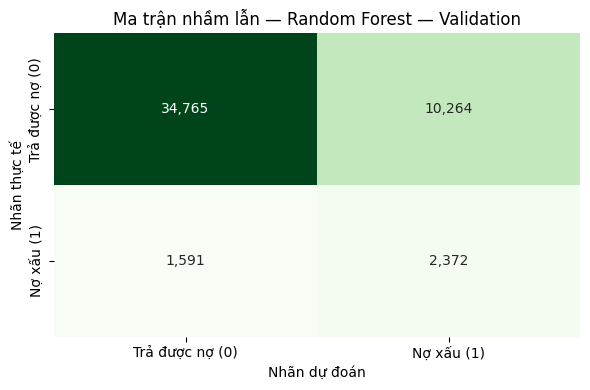

In [65]:
get_ipython().run_line_magic(
    "matplotlib",
    "inline",
)

fig, ax = plt.subplots(
    figsize=(6, 4)
)

sns.heatmap(
    ma_tran_rf,
    annot=True,
    fmt=",d",
    cmap="Greens",
    cbar=False,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=ax,
)

ax.set_xlabel("Nhãn dự đoán")
ax.set_ylabel("Nhãn thực tế")

ax.set_title(
    "Ma trận nhầm lẫn — Random Forest — Validation"
)

fig.tight_layout()
plt.show()

#### b. Các chỉ số đánh giá

Đoạn code bên dưới tính ROC-AUC, PR-AUC, Precision, Recall và F1-score của Random Forest trên tập Validation.

In [66]:
chi_so_rf_val = {
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_proba_rf,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_proba_rf,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_rf,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_rf,
        zero_division=0,
    ),
    "F1-Score": f1_score(
        y_val,
        y_val_pred_rf,
        zero_division=0,
    ),
}

Đoạn code bên dưới hiển thị các metric chính và tỷ lệ nợ xấu thực tế của tập Validation.

In [67]:
bang_chi_so_rf = pd.DataFrame(
    [chi_so_rf_val],
    index=["Random Forest"],
)

display(
    bang_chi_so_rf.round(4)
)

print(
    f"Tỷ lệ nợ xấu thực tế ở Validation: "
    f"{y_val.mean():.4f}"
)

,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
Random Forest,0.7601,0.2438,0.1877,0.5985,0.2858


Tỷ lệ nợ xấu thực tế ở Validation: 0.0809


**Nhận xét:**

- Random Forest được đánh giá trên cùng tập Validation và cùng ngưỡng tạm thời `0,5` như Logistic Regression.
- Precision, Recall và F1-score phản ánh chất lượng phân loại tại ngưỡng hiện tại, trong khi ROC-AUC và PR-AUC phản ánh khả năng phân biệt và xếp hạng rủi ro từ xác suất dự đoán.
- Kết quả cụ thể sẽ được đối chiếu với Logistic Regression và HistGradientBoosting sau khi cả ba mô hình được chạy lại trên cùng cấu trúc dữ liệu.

### 6. Phân tích Feature Importance

Random Forest cung cấp `feature_importances_`, phản ánh mức độ các feature được sử dụng trong quá trình xây dựng các cây quyết định.

Giá trị Feature Importance lớn hơn cho thấy feature có vai trò lớn hơn trong mô hình, nhưng không cho biết feature làm rủi ro tăng hay giảm và không chứng minh quan hệ nguyên nhân–kết quả.

Đoạn code bên dưới hiển thị 20 feature quan trọng nhất của Random Forest.

In [68]:
do_quan_trong_rf = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_NAMES,
).sort_values(
    ascending=False
)

top_20_rf = (
    do_quan_trong_rf.head(20)
)

Đoạn code bên dưới trình bày 20 feature quan trọng nhất dưới dạng bảng.

In [69]:
bang_quan_trong_rf = (
    top_20_rf
    .rename("Feature Importance")
    .reset_index()
)

bang_quan_trong_rf.columns = [
    "Feature",
    "Feature Importance",
]

display(
    bang_quan_trong_rf.round(4)
)

,Feature,Feature Importance
0,ext_sources_mean,0.0905
1,ext_ltv_interaction,0.0898
2,ext_min_ltv_interaction,0.0634
3,ext_sources_min,0.0563
4,ext_source_2,0.0415
5,ext_source_3,0.0318
6,ext_bureau_debt_interaction,0.0208
7,ext_dti_interaction,0.0196
8,ext_sources_std,0.0180
9,ext_source_1,0.0156


Đoạn code bên dưới vẽ biểu đồ 20 feature quan trọng nhất.

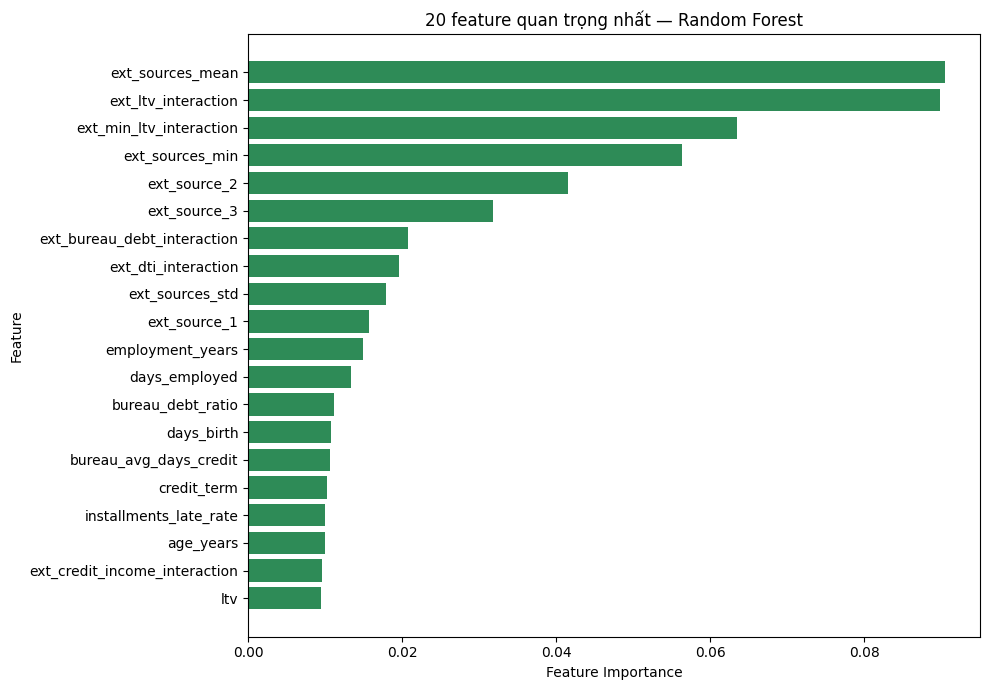

In [70]:
# Hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

plt.figure(figsize=(10, 7))
plt.barh(top_20_rf.index[::-1], top_20_rf.values[::-1], color="#2E8B57")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("20 feature quan trọng nhất — Random Forest")
plt.tight_layout()
plt.show()

**Nhận xét:**

- Feature Importance cho phép xác định các feature được Random Forest sử dụng nhiều trong quá trình phân loại rủi ro.
- Thứ hạng và giá trị cụ thể của các feature sẽ được diễn giải sau khi Notebook 06 được chạy lại với tập Train và Validation mới.
- Feature Importance không cho biết chiều tác động của feature và không chứng minh rằng một feature trực tiếp gây ra nợ xấu.

### 7. Lưu mô hình Random Forest

Đoạn code bên dưới lưu Random Forest và các metric để sử dụng ở phần so sánh, lựa chọn mô hình.

In [71]:
metrics_rf = {
    "model_name":
        "Credit Risk Classification - Random Forest",

    "model_type":
        type(rf_model).__name__,

    "model_version":
        "1.0.0",

    "status":
        "Candidate",

    "dataset":
        "application_features",

    "target":
        TARGET_COLUMN,

    "trained_date":
        datetime.now().strftime(
            "%Y-%m-%d %H:%M"
        ),

    "trained_from":
        "06_modeling_evaluation.ipynb",

    "train_rows":
        len(X_train_rf),

    "validation_rows":
        len(X_val_rf),

    "data_split":
        "64/16/20 Stratified",

    "features_count":
        len(FEATURE_NAMES),

    "decision_threshold":
        NGUONG_TAM_THOI_RF,

    "roc_auc_validation":
        round(
            float(
                chi_so_rf_val["ROC-AUC"]
            ),
            4,
        ),

    "pr_auc_validation":
        round(
            float(
                chi_so_rf_val["PR-AUC"]
            ),
            4,
        ),

    "precision_validation":
        round(
            float(
                chi_so_rf_val["Precision"]
            ),
            4,
        ),

    "recall_validation":
        round(
            float(
                chi_so_rf_val["Recall"]
            ),
            4,
        ),

    "f1_validation":
        round(
            float(
                chi_so_rf_val["F1-Score"]
            ),
            4,
        ),

    "confusion_matrix_validation":
        ma_tran_rf.tolist(),

    "author":
        "Nhóm 01",
}

Đoạn code bên dưới đóng gói Random Forest cùng danh sách feature, ngưỡng tạm thời và metric Validation.

In [72]:
goi_random_forest = {
    "model":
        rf_model,

    "feature_names":
        FEATURE_NAMES,

    "can_chuan_hoa":
        False,

    "nguong_tam_thoi":
        NGUONG_TAM_THOI_RF,

    "metrics_validation":
        metrics_rf,
}

Đoạn code bên dưới xác định đường dẫn lưu mô hình và file metric của Random Forest.

In [73]:
duong_dan_rf = (
    MODELS_DIR
    / "random_forest.pkl"
)

duong_dan_metrics_rf = (
    MODELS_DIR
    / "random_forest_metrics.json"
)

Đoạn code bên dưới lưu mô hình Random Forest vào thư mục `models`.

In [74]:
joblib.dump(
    goi_random_forest,
    duong_dan_rf,
)

print(
    f"Đã lưu mô hình: "
    f"{duong_dan_rf}"
)

Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\random_forest.pkl


Đoạn code bên dưới lưu metadata và metric Validation của Random Forest dưới dạng JSON.

In [75]:
duong_dan_metrics_rf.write_text(
    json.dumps(
        metrics_rf,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    f"Đã lưu metric: "
    f"{duong_dan_metrics_rf}"
)

Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\random_forest_metrics.json


Đoạn code bên dưới hiển thị lại các metric chính đã lưu để kiểm tra kết quả.

In [76]:
display(
    pd.DataFrame(
        [{
            "ROC-AUC":
                metrics_rf["roc_auc_validation"],

            "PR-AUC":
                metrics_rf["pr_auc_validation"],

            "Precision":
                metrics_rf["precision_validation"],

            "Recall":
                metrics_rf["recall_validation"],

            "F1-Score":
                metrics_rf["f1_validation"],
        }],
        index=[
            "Random Forest"
        ],
    )
)

,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
Random Forest,0.7601,0.2438,0.1877,0.5985,0.2858


## VI. Mô hình HistGradientBoosting

### 1. Giới thiệu HistGradientBoosting

HistGradientBoosting xây dựng nhiều cây quyết định theo thứ tự. Mỗi cây mới tập trung sửa những lỗi mà các cây trước còn dự đoán sai.

Có thể hình dung một nhóm nhân viên tín dụng đánh giá lần lượt. Người sau xem lại các hồ sơ mà những người trước xử lý chưa tốt và điều chỉnh kết quả từng bước.

Khác với Random Forest xây dựng nhiều cây tương đối độc lập, HistGradientBoosting cho các cây học nối tiếp nhau. Mô hình còn chia giá trị số thành các khoảng (`histogram`) để huấn luyện nhanh hơn trên dữ liệu lớn.

### 2. Lựa chọn feature đầu vào

HistGradientBoosting không yêu cầu chuẩn hóa dữ liệu. Đoạn code bên dưới sử dụng dữ liệu đã xử lý missing và one-hot encoding ở Mục III cho Train và Validation.

In [77]:
# HistGradientBoosting sử dụng dữ liệu đã xử lý nhưng chưa chuẩn hóa.
X_train_hgb = X_train_prep
X_val_hgb = X_val_prep

# Kiểm tra Train và Validation có cùng cấu trúc feature.
assert list(X_train_hgb.columns) == FEATURE_NAMES
assert list(X_val_hgb.columns) == FEATURE_NAMES

# Kiểm tra không còn giá trị thiếu.
assert not X_train_hgb.isna().any().any()
assert not X_val_hgb.isna().any().any()

Đoạn code bên dưới tóm tắt kích thước dữ liệu đầu vào của HistGradientBoosting.

In [78]:
bang_du_lieu_hgb = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation"],
    "Số dòng": [
        len(X_train_hgb),
        len(X_val_hgb),
    ],
    "Số feature": [
        X_train_hgb.shape[1],
        X_val_hgb.shape[1],
    ],
    "Số ô thiếu": [
        int(X_train_hgb.isna().sum().sum()),
        int(X_val_hgb.isna().sum().sum()),
    ],
})

display(bang_du_lieu_hgb)

,Tập dữ liệu,Số dòng,Số feature,Số ô thiếu
0,Train,195964,397,0
1,Validation,48992,397,0


### 3. Huấn luyện mô hình

Các tham số chính của HistGradientBoosting:

- `max_iter=200`: số vòng boosting tối đa.
- `learning_rate=0.1`: mức điều chỉnh của mô hình sau mỗi vòng.
- `max_leaf_nodes=31`: giới hạn số nút lá của mỗi cây.
- `min_samples_leaf=50`: mỗi nút lá phải có ít nhất 50 khách hàng.
- `class_weight="balanced"`: điều chỉnh trọng số để tăng mức quan tâm tới lớp nợ xấu đang chiếm tỷ lệ thấp.
- `random_state=42`: giúp kết quả có thể lặp lại.

Đoạn code bên dưới khởi tạo HistGradientBoosting trên tập Train.

In [79]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
)

Đoạn code bên dưới huấn luyện HistGradientBoosting trên tập Train và đo thời gian thực hiện.

In [80]:
bat_dau = time.time()

hgb_model.fit(
    X_train_hgb,
    y_train,
)

thoi_gian_hgb = time.time() - bat_dau

Đoạn code bên dưới kiểm tra số vòng boosting thực tế đã được thực hiện.

In [81]:
print(
    f"Thời gian huấn luyện: "
    f"{thoi_gian_hgb:.1f} giây"
)

print(
    f"Số vòng đã thực hiện: "
    f"{hgb_model.n_iter_:,} / {hgb_model.max_iter}"
)

Thời gian huấn luyện: 17.5 giây
Số vòng đã thực hiện: 104 / 200


### 4. Dự đoán trên tập Validation

Đoạn code bên dưới lấy xác suất khách hàng thuộc nhóm nợ xấu (`target=1`) trên tập Validation.

In [82]:
y_val_proba_hgb = hgb_model.predict_proba(
    X_val_hgb
)[:, 1]

assert len(y_val_proba_hgb) == len(y_val)

assert np.all(
    (y_val_proba_hgb >= 0)
    & (y_val_proba_hgb <= 1)
)

Ngưỡng `0,5` được sử dụng tạm thời để chuyển xác suất thành nhãn dự đoán, nhằm đảm bảo HistGradientBoosting được so sánh với Logistic Regression và Random Forest trong cùng điều kiện.

In [83]:
NGUONG_TAM_THOI_HGB = 0.5

y_val_pred_hgb = (
    y_val_proba_hgb >= NGUONG_TAM_THOI_HGB
).astype(int)

Đoạn code bên dưới hiển thị 10 dự đoán đầu tiên của HistGradientBoosting trên tập Validation.

In [84]:
du_doan_mau_hgb = pd.DataFrame({
    "Nhãn thực tế": y_val.iloc[:10].to_numpy(),
    "Xác suất nợ xấu": y_val_proba_hgb[:10],
    "Nhãn dự đoán": y_val_pred_hgb[:10],
}, index=y_val.index[:10])

display(
    du_doan_mau_hgb.round(4)
)

,Nhãn thực tế,Xác suất nợ xấu,Nhãn dự đoán
174344,0,0.6856,1
194595,0,0.2132,0
248713,1,0.8613,1
34504,0,0.4271,0
253056,0,0.6721,1
32721,0,0.5759,1
284781,0,0.3793,0
95590,1,0.8717,1
78746,0,0.3626,0
284304,0,0.5727,1


### 5. Đánh giá mô hình

HistGradientBoosting được đánh giá trên cùng tập Validation và cùng ngưỡng tạm thời `0,5` như Logistic Regression và Random Forest để đảm bảo việc so sánh giữa ba mô hình là nhất quán.

#### a. Ma trận nhầm lẫn

Đoạn code bên dưới tính ma trận nhầm lẫn của HistGradientBoosting trên tập Validation.

In [85]:
ma_tran_hgb = confusion_matrix(
    y_val,
    y_val_pred_hgb,
)

tn_hgb, fp_hgb, fn_hgb, tp_hgb = (
    ma_tran_hgb.ravel()
)

Đoạn code bên dưới trình bày ma trận nhầm lẫn dưới dạng bảng và tóm tắt số khách nợ xấu được phát hiện, bị bỏ sót và số cảnh báo nhầm.

In [86]:
bang_ma_tran_hgb = pd.DataFrame(
    ma_tran_hgb,
    index=[
        "Thực tế: Trả được nợ",
        "Thực tế: Nợ xấu",
    ],
    columns=[
        "Dự đoán: Trả được nợ",
        "Dự đoán: Nợ xấu",
    ],
)

display(bang_ma_tran_hgb)

print(f"Phát hiện đúng nợ xấu: {tp_hgb:,}")
print(f"Bỏ sót nợ xấu: {fn_hgb:,}")
print(f"Cảnh báo nhầm: {fp_hgb:,}")

,Dự đoán: Trả được nợ,Dự đoán: Nợ xấu
Thực tế: Trả được nợ,33050,11979
Thực tế: Nợ xấu,1282,2681


Phát hiện đúng nợ xấu: 2,681
Bỏ sót nợ xấu: 1,282
Cảnh báo nhầm: 11,979


Đoạn code bên dưới vẽ ma trận nhầm lẫn của HistGradientBoosting.

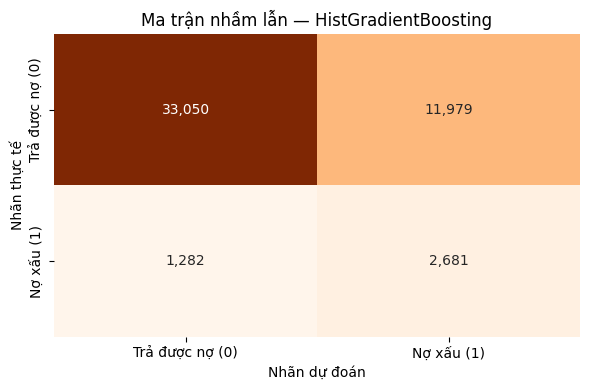

In [87]:
# Hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

plt.figure(figsize=(6, 4))
sns.heatmap(
    ma_tran_hgb,
    annot=True,
    fmt=",d",
    cmap="Oranges",
    cbar=False,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
)
plt.xlabel("Nhãn dự đoán")
plt.ylabel("Nhãn thực tế")
plt.title("Ma trận nhầm lẫn — HistGradientBoosting")
plt.tight_layout()
plt.show()

#### b. Các chỉ số đánh giá

Đoạn code bên dưới tính ROC-AUC, PR-AUC, Precision, Recall và F1-score của HistGradientBoosting trên tập Validation.

In [88]:
chi_so_hgb_val = {
    "ROC-AUC": roc_auc_score(
        y_val,
        y_val_proba_hgb,
    ),
    "PR-AUC": average_precision_score(
        y_val,
        y_val_proba_hgb,
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred_hgb,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred_hgb,
        zero_division=0,
    ),
    "F1-Score": f1_score(
        y_val,
        y_val_pred_hgb,
        zero_division=0,
    ),
}

Đoạn code bên dưới hiển thị các metric chính và tỷ lệ nợ xấu thực tế của tập Validation.

In [89]:
bang_chi_so_hgb = pd.DataFrame(
    [chi_so_hgb_val],
    index=["HistGradientBoosting"],
)

display(
    bang_chi_so_hgb.round(4)
)

print(
    f"Tỷ lệ nợ xấu thực tế ở Validation: "
    f"{y_val.mean():.4f}"
)

,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
HistGradientBoosting,0.7745,0.2598,0.1829,0.6765,0.2879


Tỷ lệ nợ xấu thực tế ở Validation: 0.0809


**Nhận xét:**

- HistGradientBoosting được đánh giá trên cùng tập Validation và cùng ngưỡng tạm thời `0,5` như hai mô hình trước.
- ROC-AUC và PR-AUC phản ánh khả năng phân biệt và xếp hạng rủi ro của mô hình, trong khi Precision, Recall và F1-score phản ánh kết quả phân loại tại ngưỡng hiện tại.
- Việc lựa chọn mô hình sẽ chỉ được thực hiện sau khi kết quả của cả ba mô hình được tổng hợp ở Mục VII.

### 6. Phân tích Permutation Importance

HistGradientBoosting không cung cấp trực tiếp `feature_importances_` như Random Forest. Vì vậy, Permutation Importance được sử dụng để đánh giá mức đóng góp tương đối của từng feature.

Phương pháp này lần lượt đảo ngẫu nhiên giá trị của một feature, sau đó đo mức suy giảm PR-AUC của mô hình. PR-AUC giảm càng nhiều thì feature đó càng có vai trò quan trọng đối với kết quả dự đoán.

Permutation Importance không cho biết chiều tác động của feature và không chứng minh quan hệ nguyên nhân–kết quả.

#### a. Xác định 20 feature quan trọng nhất

Để giảm thời gian tính toán, đoạn code bên dưới lấy tối đa 10.000 dòng từ tập Validation bằng `random_state=42`.

Tập Test không được sử dụng trong bước phân tích này.

In [90]:
so_mau_importance = min(
    10_000,
    len(X_val_hgb),
)

X_importance_hgb = X_val_hgb.sample(
    n=so_mau_importance,
    random_state=42,
)

Đoạn code bên dưới lấy đúng target tương ứng với các dòng Validation đã được chọn.

In [91]:
y_importance_hgb = y_val.loc[
    X_importance_hgb.index
]

assert len(X_importance_hgb) == len(
    y_importance_hgb
)

print(
    f"Số dòng dùng tính Permutation Importance: "
    f"{len(X_importance_hgb):,}"
)

print(
    f"Tỷ lệ nợ xấu trong mẫu: "
    f"{y_importance_hgb.mean():.4f}"
)

Số dòng dùng tính Permutation Importance: 10,000
Tỷ lệ nợ xấu trong mẫu: 0.0807


Đoạn code bên dưới thực hiện Permutation Importance với PR-AUC làm tiêu chí đánh giá. Mỗi feature được đảo ngẫu nhiên 3 lần và lấy mức suy giảm trung bình.

In [92]:
bat_dau = time.time()

ket_qua_importance_hgb = permutation_importance(
    hgb_model,
    X_importance_hgb,
    y_importance_hgb,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
)

thoi_gian_importance_hgb = (
    time.time() - bat_dau
)

Đoạn code bên dưới ghép kết quả Permutation Importance với đúng tên feature và sắp xếp theo mức giảm PR-AUC.

In [93]:
do_quan_trong_hgb = pd.Series(
    ket_qua_importance_hgb.importances_mean,
    index=FEATURE_NAMES,
).sort_values(
    ascending=False
)

Đoạn code bên dưới lấy 20 feature có Permutation Importance cao nhất.

In [94]:
top_20_hgb = (
    do_quan_trong_hgb.head(20)
)

Đoạn code bên dưới trình bày 20 feature quan trọng nhất dưới dạng bảng.

In [95]:
bang_quan_trong_hgb = (
    top_20_hgb
    .rename("Độ giảm PR-AUC")
    .reset_index()
)

bang_quan_trong_hgb.columns = [
    "Feature",
    "Độ giảm PR-AUC",
]

display(
    bang_quan_trong_hgb.round(4)
)

print(
    f"Thời gian tính Permutation Importance: "
    f"{thoi_gian_importance_hgb:.1f} giây"
)

,Feature,Độ giảm PR-AUC
0,ext_ltv_interaction,0.0223
1,ext_sources_mean,0.0149
2,code_gender_F,0.0087
3,credit_term,0.0086
4,ext_source_1,0.0073
5,previous_refusal_rate,0.0051
6,bureau_sum_credit,0.0040
7,installments_sum_paid,0.0030
8,name_education_type_Higher education,0.0024
9,name_income_type_Working,0.0021


Thời gian tính Permutation Importance: 31.1 giây


**Nhận xét:**

- Permutation Importance được tính trên một mẫu cố định từ tập Validation, không sử dụng tập Test.
- Feature có độ giảm PR-AUC lớn hơn được xem là có vai trò lớn hơn đối với khả năng dự đoán của HistGradientBoosting.
- Thứ hạng và giá trị cụ thể của các feature sẽ được diễn giải sau khi Notebook 06 được chạy lại hoàn chỉnh.

#### b. Kiểm tra độ quan trọng của 8 feature vòng 1

Đoạn code bên dưới hiển thị độ quan trọng và thứ hạng của 8 feature đã bổ sung ở vòng 1.


In [96]:
# Danh sách 8 feature vòng 1 từ NB02.
feature_vong_1 = [
    "installments_underpaid_count",
    "installments_underpaid_amount",
    "installments_recent_12m_late_count",
    "credit_card_contract_count",
    "credit_card_avg_utilization",
    "credit_card_max_utilization",
    "pos_cash_contract_count",
    "pos_cash_recent_12m_dpd_count",
]

# Tạo bảng thứ hạng của toàn bộ feature.
xep_hang_hgb = do_quan_trong_hgb.reset_index()
xep_hang_hgb.columns = ["Feature", "Độ giảm PR-AUC"]
xep_hang_hgb["Xếp hạng"] = range(1, len(xep_hang_hgb) + 1)

# Chỉ lấy 8 feature vòng 1 và sắp xếp từ quan trọng nhất.
bang_quan_trong_vong_1 = xep_hang_hgb[
    xep_hang_hgb["Feature"].isin(feature_vong_1)
].copy()
assert len(bang_quan_trong_vong_1) == len(feature_vong_1), (
    "Có feature vòng 1 không tồn tại trong kết quả Permutation Importance."
)
bang_quan_trong_vong_1["Trong top 20"] = np.where(
    bang_quan_trong_vong_1["Xếp hạng"] <= 20, "Có", "Không"
)

display(bang_quan_trong_vong_1.round({"Độ giảm PR-AUC": 4}))


,Feature,Độ giảm PR-AUC,Xếp hạng,Trong top 20
73,credit_card_avg_utilization,0.0001,74,Không
125,pos_cash_recent_12m_dpd_count,0.0000,126,Không
141,credit_card_contract_count,0.0000,142,Không
279,installments_underpaid_amount,-0.0000,280,Không
289,pos_cash_contract_count,-0.0000,290,Không
335,installments_underpaid_count,-0.0001,336,Không
384,installments_recent_12m_late_count,-0.0006,385,Không
389,credit_card_max_utilization,-0.0008,390,Không


**Nhận xét:**

- Bảng trên cho biết thứ hạng Permutation Importance của 8 feature được bổ sung ở vòng 1 trên tập Validation.
- Kết quả giúp kiểm tra liệu các feature này còn cung cấp tín hiệu đáng kể sau khi kết hợp với toàn bộ feature ở các vòng sau.
- Thứ hạng cụ thể được diễn giải dựa trên kết quả chạy hiện tại, không sử dụng kết quả Permutation Importance cũ trên Test.

#### c. Kiểm tra độ quan trọng của 10 feature vòng 2

Đoạn code bên dưới hiển thị độ quan trọng và thứ hạng của 8 summary feature mới cùng 2 tỷ lệ được tạo tại NB05.


In [97]:
# Tám summary feature mới từ NB02 và hai tỷ lệ mới từ NB05.
feature_vong_2 = [
    "bureau_recent_12m_overdue_count",
    "previous_recent_12m_approved_count",
    "previous_recent_12m_refused_count",
    "installments_recent_12m_count",
    "installments_recent_12m_underpaid_count",
    "installments_recent_12m_underpaid_amount",
    "credit_card_recent_12m_max_utilization",
    "pos_cash_recent_12m_max_dpd",
    "installments_recent_12m_late_rate",
    "installments_recent_12m_underpaid_rate",
]

# Lấy thứ hạng của 10 feature vòng 2.
bang_quan_trong_vong_2 = xep_hang_hgb[
    xep_hang_hgb["Feature"].isin(feature_vong_2)
].copy()
assert len(bang_quan_trong_vong_2) == len(feature_vong_2), (
    "Có feature vòng 2 không tồn tại trong kết quả Permutation Importance."
)
bang_quan_trong_vong_2["Trong top 20"] = np.where(
    bang_quan_trong_vong_2["Xếp hạng"] <= 20, "Có", "Không"
)

display(bang_quan_trong_vong_2.round({"Độ giảm PR-AUC": 4}))


,Feature,Độ giảm PR-AUC,Xếp hạng,Trong top 20
11,credit_card_recent_12m_max_utilization,0.0021,12,Có
47,bureau_recent_12m_overdue_count,0.0004,48,Không
102,installments_recent_12m_underpaid_count,0.0000,103,Không
106,previous_recent_12m_approved_count,0.0000,107,Không
309,previous_recent_12m_refused_count,-0.0000,310,Không
336,installments_recent_12m_count,-0.0001,337,Không
340,installments_recent_12m_underpaid_rate,-0.0002,341,Không
381,pos_cash_recent_12m_max_dpd,-0.0006,382,Không
394,installments_recent_12m_underpaid_amount,-0.0012,395,Không
395,installments_recent_12m_late_rate,-0.0017,396,Không


**Nhận xét:**

- Bảng trên cho biết mức đóng góp tương đối của 10 feature được bổ sung ở vòng 2 trong HistGradientBoosting hiện tại.
- Feature có thứ hạng cao và độ giảm PR-AUC lớn hơn cho thấy mô hình phụ thuộc nhiều hơn vào feature đó trên tập Validation.
- Permutation Importance được sử dụng để kiểm chứng tín hiệu của feature, không đủ để khẳng định riêng feature đó làm tăng metric tổng thể.

#### d. Kiểm tra độ quan trọng của 4 feature vòng 3

Đoạn code bên dưới hiển thị độ quan trọng và thứ hạng của 4 interaction feature được tạo tại NB05.


In [98]:
# Bốn interaction feature được bổ sung ở vòng 3.
feature_vong_3 = [
    "ext_credit_income_interaction",
    "ext_dti_interaction",
    "ext_min_ltv_interaction",
    "ext_bureau_debt_interaction",
]

# Lấy thứ hạng của 4 feature vòng 3.
bang_quan_trong_vong_3 = xep_hang_hgb[
    xep_hang_hgb["Feature"].isin(feature_vong_3)
].copy()
assert len(bang_quan_trong_vong_3) == len(feature_vong_3), (
    "Có feature vòng 3 không tồn tại trong kết quả Permutation Importance."
)
bang_quan_trong_vong_3["Trong top 20"] = np.where(
    bang_quan_trong_vong_3["Xếp hạng"] <= 20, "Có", "Không"
)

display(bang_quan_trong_vong_3.round({"Độ giảm PR-AUC": 4}))


,Feature,Độ giảm PR-AUC,Xếp hạng,Trong top 20
39,ext_credit_income_interaction,0.0005,40,Không
48,ext_dti_interaction,0.0004,49,Không
342,ext_bureau_debt_interaction,-0.0002,343,Không
393,ext_min_ltv_interaction,-0.0009,394,Không


**Nhận xét:**

- Bảng trên giúp kiểm tra mức đóng góp của 4 interaction feature được bổ sung ở vòng 3.
- Nếu các interaction có thứ hạng thấp hoặc độ giảm PR-AUC nhỏ, điều đó cho thấy tín hiệu của chúng có thể đã được phản ánh một phần bởi các feature nguồn.
- Kết quả Permutation Importance chỉ phản ánh mức phụ thuộc của mô hình vào feature trên Validation và không chứng minh quan hệ nguyên nhân–kết quả.

Đoạn code bên dưới vẽ biểu đồ 20 feature quan trọng nhất.

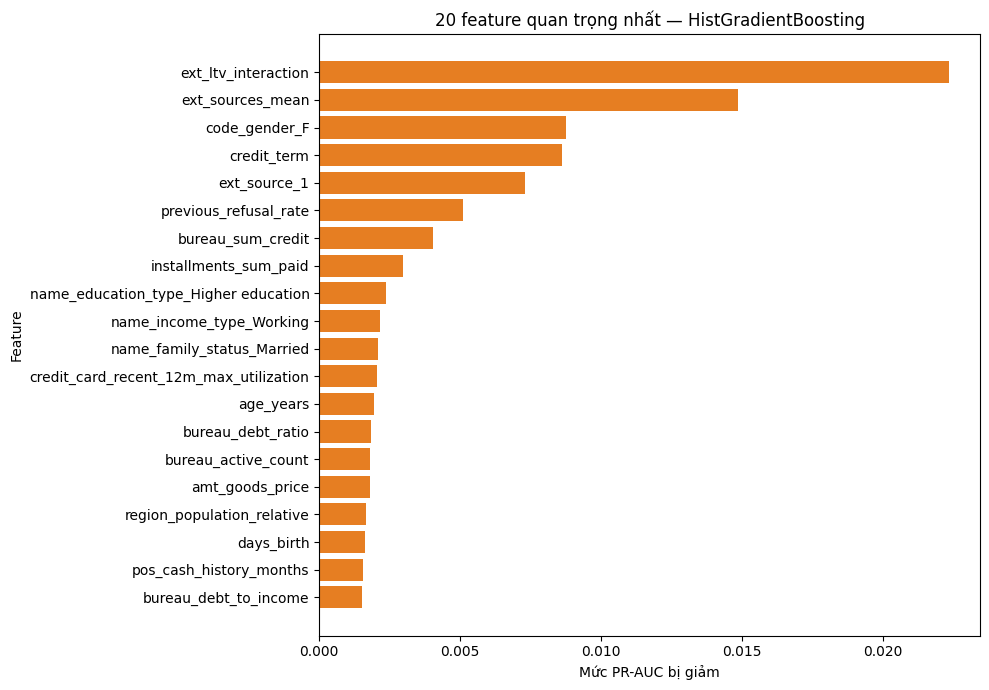

In [99]:
# Hiển thị biểu đồ ngay trong notebook.
get_ipython().run_line_magic("matplotlib", "inline")

plt.figure(figsize=(10, 7))
plt.barh(top_20_hgb.index[::-1], top_20_hgb.values[::-1], color="#E67E22")
plt.xlabel("Mức PR-AUC bị giảm")
plt.ylabel("Feature")
plt.title("20 feature quan trọng nhất — HistGradientBoosting")
plt.tight_layout()
plt.show()

### 7. Lưu mô hình HistGradientBoosting

Đoạn code bên dưới lưu HistGradientBoosting và các metric để sử dụng ở phần so sánh, lựa chọn mô hình.

In [ ]:
metrics_hgb = {
    "model_name":
        "Credit Risk Classification - HistGradientBoosting",

    "model_type":
        type(hgb_model).__name__,

    "model_version":
        "1.0.0",

    "status":
        "Candidate",

    "dataset":
        "application_features",

    "target":
        TARGET_COLUMN,

    "trained_date":
        datetime.now().strftime(
            "%Y-%m-%d %H:%M"
        ),

    "trained_from":
        "06_modeling_evaluation.ipynb",

    "train_rows":
        len(X_train_hgb),

    "validation_rows":
        len(X_val_hgb),

    "data_split":
        "64/16/20 Stratified",

    "features_count":
        len(FEATURE_NAMES),

    "decision_threshold":
        NGUONG_TAM_THOI_HGB,

    "roc_auc_validation":
        round(
            float(
                chi_so_hgb_val["ROC-AUC"]
            ),
            4,
        ),

    "pr_auc_validation":
        round(
            float(
                chi_so_hgb_val["PR-AUC"]
            ),
            4,
        ),

    "precision_validation":
        round(
            float(
                chi_so_hgb_val["Precision"]
            ),
            4,
        ),

    "recall_validation":
        round(
            float(
                chi_so_hgb_val["Recall"]
            ),
            4,
        ),

    "f1_validation":
        round(
            float(
                chi_so_hgb_val["F1-Score"]
            ),
            4,
        ),

    "confusion_matrix_validation":
        ma_tran_hgb.tolist(),

    "author":
        "Nhóm 01",
}

Đoạn code bên dưới đóng gói HistGradientBoosting cùng danh sách feature, ngưỡng tạm thời và metric Validation.

In [102]:
goi_hist_gradient_boosting = {
    "model":
        hgb_model,

    "feature_names":
        FEATURE_NAMES,

    "can_chuan_hoa":
        False,

    "nguong_tam_thoi":
        NGUONG_TAM_THOI_HGB,

    "metrics_validation":
        metrics_hgb,
}

Đoạn code bên dưới xác định đường dẫn lưu mô hình và file metric của HistGradientBoosting.

In [103]:
duong_dan_hgb = (
    MODELS_DIR
    / "hist_gradient_boosting.pkl"
)

duong_dan_metrics_hgb = (
    MODELS_DIR
    / "hist_gradient_boosting_metrics.json"
)

Đoạn code bên dưới lưu mô hình HistGradientBoosting vào thư mục `models`.

In [104]:
joblib.dump(
    goi_hist_gradient_boosting,
    duong_dan_hgb,
)

print(
    f"Đã lưu mô hình: "
    f"{duong_dan_hgb}"
)

Đã lưu mô hình: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting.pkl


Đoạn code bên dưới lưu metadata và metric Validation của HistGradientBoosting dưới dạng JSON.

In [105]:
duong_dan_metrics_hgb.write_text(
    json.dumps(
        metrics_hgb,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    f"Đã lưu metric: "
    f"{duong_dan_metrics_hgb}"
)

Đã lưu metric: d:\FPT Polytechnic\2026\HK Summer 2026\Block2\Du-an-01\credit-risk-classifier\models\hist_gradient_boosting_metrics.json


Đoạn code bên dưới hiển thị lại các metric chính đã lưu để kiểm tra kết quả.

In [106]:
display(
    pd.DataFrame(
        [{
            "ROC-AUC":
                metrics_hgb["roc_auc_validation"],

            "PR-AUC":
                metrics_hgb["pr_auc_validation"],

            "Precision":
                metrics_hgb["precision_validation"],

            "Recall":
                metrics_hgb["recall_validation"],

            "F1-Score":
                metrics_hgb["f1_validation"],
        }],
        index=[
            "HistGradientBoosting"
        ],
    )
)

,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
HistGradientBoosting,0.7745,0.2598,0.1829,0.6765,0.2879


## VII. So sánh các mô hình

### 1. Bảng tổng hợp kết quả

Đoạn code bên dưới tổng hợp kết quả của ba mô hình trên cùng tập Validation và cùng ngưỡng tạm thời `0,5` để phục vụ bước lựa chọn mô hình.

In [107]:
# Gom kết quả của ba mô hình trên cùng tập Validation.
bang_so_sanh_mo_hinh = pd.DataFrame({
    "Mô hình": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting",
    ],
    "Thời gian (giây)": [
        thoi_gian_lr,
        thoi_gian_rf,
        thoi_gian_hgb,
    ],
    "ROC-AUC": [
        chi_so_lr_val["ROC-AUC"],
        chi_so_rf_val["ROC-AUC"],
        chi_so_hgb_val["ROC-AUC"],
    ],
    "PR-AUC": [
        chi_so_lr_val["PR-AUC"],
        chi_so_rf_val["PR-AUC"],
        chi_so_hgb_val["PR-AUC"],
    ],
    "Precision": [
        chi_so_lr_val["Precision"],
        chi_so_rf_val["Precision"],
        chi_so_hgb_val["Precision"],
    ],
    "Recall": [
        chi_so_lr_val["Recall"],
        chi_so_rf_val["Recall"],
        chi_so_hgb_val["Recall"],
    ],
    "F1-score": [
        chi_so_lr_val["F1-Score"],
        chi_so_rf_val["F1-Score"],
        chi_so_hgb_val["F1-Score"],
    ],
})

# Làm tròn thời gian huấn luyện.
bang_so_sanh_mo_hinh["Thời gian (giây)"] = (
    bang_so_sanh_mo_hinh["Thời gian (giây)"].round(1)
)

# Làm tròn các metric để bảng dễ đọc.
cac_cot_metric = [
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1-score",
]

bang_so_sanh_mo_hinh[cac_cot_metric] = (
    bang_so_sanh_mo_hinh[cac_cot_metric].round(4)
)

display(bang_so_sanh_mo_hinh)

,Mô hình,Thời gian (giây),ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Logistic Regression,24.3,0.7667,0.2463,0.1729,0.6881,0.2763
1,Random Forest,74.5,0.7601,0.2438,0.1877,0.5985,0.2858
2,HistGradientBoosting,17.5,0.7745,0.2598,0.1829,0.6765,0.2879


**Nhận xét:**

- HistGradientBoosting đạt kết quả tốt nhất về ROC-AUC (`0,7745`), PR-AUC (`0,2598`) và F1-score (`0,2879`), đồng thời có thời gian huấn luyện thấp nhất trong ba mô hình (`17,5` giây).
- Random Forest có Precision cao nhất (`0,1877`) nhưng Recall thấp nhất (`0,5985`) và PR-AUC (`0,2438`) cũng thấp hơn HistGradientBoosting.
- Logistic Regression có Recall cao nhất (`0,6881`) nhưng Precision thấp nhất (`0,1729`), cho thấy mô hình phát hiện được nhiều khách nợ xấu hơn nhưng tạo nhiều cảnh báo nhầm hơn.
- Xét tổng thể khả năng phân biệt rủi ro và sự cân bằng giữa Precision–Recall trên tập Validation, nhóm chọn **HistGradientBoosting** làm mô hình ứng viên để tiếp tục tối ưu ngưỡng dự đoán tại Notebook 06.1.

## VIII. Tổng kết

- Ba mô hình Logistic Regression, Random Forest và HistGradientBoosting được huấn luyện trên cùng tập Train và đánh giá trên cùng tập Validation tại ngưỡng tạm thời `0,5`.
- HistGradientBoosting cho kết quả tốt nhất về ROC-AUC (`0,7745`), PR-AUC (`0,2598`) và F1-score (`0,2879`), đồng thời có thời gian huấn luyện thấp nhất trong ba mô hình.
- Random Forest có Precision cao nhất (`0,1877`) nhưng Recall thấp nhất (`0,5985`), trong khi Logistic Regression có Recall cao nhất (`0,6881`) nhưng Precision thấp nhất (`0,1729`).
- Xét tổng thể khả năng phân biệt rủi ro và sự cân bằng giữa Precision–Recall trên Validation, nhóm chọn HistGradientBoosting làm mô hình ứng viên cho bước tối ưu ngưỡng.
- Tập Test được giữ riêng và chưa được sử dụng trong quá trình lựa chọn mô hình tại Notebook 06.
- Bước tiếp theo tại Notebook 06.1 là lựa chọn ngưỡng dự đoán trên Validation bằng F2-score để ưu tiên Recall và hạn chế False Negative, sau đó đánh giá cuối cùng một lần trên tập Test.
